In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sympy import *
from scipy import stats
from datetime import timedelta
import matplotlib.ticker as ticker
from sklearn import metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import datasets 
from sklearn import svm
from sklearn.model_selection import cross_validate
import nltk
from nltk.tokenize import sent_tokenize
from sklearn.model_selection import cross_val_score
from scipy.stats import ttest_ind
import seaborn as sns

In [2]:
data = 'D:/AI Course/AI Capstone Project/UpdatedTemporaryStaffList.csv'

In [3]:
Data = pd.read_csv(data)

In [4]:
Data

,RowID,AssignmentID,OrderID,Title,StartDate,ProjectedEndDate,ActualEndDate,AssignmentStatus,StandardRate,ChargeRate,HoursPerWeek,HoursInvoicedToDate,JobTitleCode,SupplierName,CreatedDate,CreatedBy,UpdatedDate,UpdatedBy
0,29605,1001,1001,NaN,26/12/2011,31/08/2013,23/01/2015,Expired,25.00,27.65,0.0,0,100000CMBR11,CARITAS RECRUITMENT LTD,31:01.6,LBB2000\devservice,31:01.6,LBB2000\devservice
1,29606,1002,1002,NaN,05/09/2012,31/08/2013,13/09/2013,Expired,23.18,25.84,0.0,0,100000CMBR11,Liquid Personnel Limited,31:01.6,LBB2000\devservice,31:01.6,LBB2000\devservice
2,29607,1003,1003,NaN,02/04/2007,31/08/2013,30/09/2015,Expired,9.59,12.60,0.0,0,100000AABR4,Falconwood Employment Agency Ltd,31:01.6,LBB2000\devservice,31:01.6,LBB2000\devservice
3,29608,1004,1004,NaN,23/09/2009,31/08/2013,23/01/2014,Expired,10.07,13.66,0.0,0,829006NCBR6,Douglas Care & Domestic Services Ltd,31:01.6,LBB2000\devservice,31:01.6,LBB2000\devservice
4,29609,1005,1005,NaN,23/09/2009,31/08/2013,23/01/2014,Expired,8.93,12.05,0.0,0,829006NCBR4,Douglas Care & Domestic Services Ltd,31:01.6,LBB2000\devservice,31:01.6,LBB2000\devservice
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6657,37732,SA562107,RQ858526,NaN,17/04/2023,10/07/2023,10/07/2023,Active,24.39,34.30,36.0,0,2925,Charles Hunter Associates Ltd,34:03.2,LBB2000\devservice,34:03.2,LBB2000\devservice
6658,37733,SA563163,RQ859615,NaN,25/04/2023,10/07/2023,20/07/2023,Active,14.23,18.78,36.0,0,15412,Liquid Personnel Ltd,34:03.2,LBB2000\devservice,34:03.2,LBB2000\devservice
6659,37734,SA559608,RQ859261,NaN,26/04/2023,10/10/2023,26/10/2023,Active,30.52,42.48,36.0,0,2681,Liquid Personnel Ltd,34:01.2,LBB2000\devservice,34:01.2,LBB2000\devservice
6660,37735,SA564031,RQ766531,NaN,09/05/2023,21/04/2023,31/08/2023,Active,24.39,34.30,36.0,0,2850,Diverse Financial Solutions Ltd ta/ Social Per...,34:01.2,LBB2000\devservice,34:01.2,LBB2000\devservice


In [5]:
Data.isnull().sum()

RowID                     0
AssignmentID              0
OrderID                   0
Title                  6662
StartDate                 0
ProjectedEndDate          0
ActualEndDate             0
AssignmentStatus          0
StandardRate              0
ChargeRate                0
HoursPerWeek              0
HoursInvoicedToDate       0
JobTitleCode             11
SupplierName              0
CreatedDate               0
CreatedBy                 0
UpdatedDate               0
UpdatedBy                 0
dtype: int64

In [6]:
Data.drop(['Title','JobTitleCode'], axis=1)

,RowID,AssignmentID,OrderID,StartDate,ProjectedEndDate,ActualEndDate,AssignmentStatus,StandardRate,ChargeRate,HoursPerWeek,HoursInvoicedToDate,SupplierName,CreatedDate,CreatedBy,UpdatedDate,UpdatedBy
0,29605,1001,1001,26/12/2011,31/08/2013,23/01/2015,Expired,25.00,27.65,0.0,0,CARITAS RECRUITMENT LTD,31:01.6,LBB2000\devservice,31:01.6,LBB2000\devservice
1,29606,1002,1002,05/09/2012,31/08/2013,13/09/2013,Expired,23.18,25.84,0.0,0,Liquid Personnel Limited,31:01.6,LBB2000\devservice,31:01.6,LBB2000\devservice
2,29607,1003,1003,02/04/2007,31/08/2013,30/09/2015,Expired,9.59,12.60,0.0,0,Falconwood Employment Agency Ltd,31:01.6,LBB2000\devservice,31:01.6,LBB2000\devservice
3,29608,1004,1004,23/09/2009,31/08/2013,23/01/2014,Expired,10.07,13.66,0.0,0,Douglas Care & Domestic Services Ltd,31:01.6,LBB2000\devservice,31:01.6,LBB2000\devservice
4,29609,1005,1005,23/09/2009,31/08/2013,23/01/2014,Expired,8.93,12.05,0.0,0,Douglas Care & Domestic Services Ltd,31:01.6,LBB2000\devservice,31:01.6,LBB2000\devservice
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6657,37732,SA562107,RQ858526,17/04/2023,10/07/2023,10/07/2023,Active,24.39,34.30,36.0,0,Charles Hunter Associates Ltd,34:03.2,LBB2000\devservice,34:03.2,LBB2000\devservice
6658,37733,SA563163,RQ859615,25/04/2023,10/07/2023,20/07/2023,Active,14.23,18.78,36.0,0,Liquid Personnel Ltd,34:03.2,LBB2000\devservice,34:03.2,LBB2000\devservice
6659,37734,SA559608,RQ859261,26/04/2023,10/10/2023,26/10/2023,Active,30.52,42.48,36.0,0,Liquid Personnel Ltd,34:01.2,LBB2000\devservice,34:01.2,LBB2000\devservice
6660,37735,SA564031,RQ766531,09/05/2023,21/04/2023,31/08/2023,Active,24.39,34.30,36.0,0,Diverse Financial Solutions Ltd ta/ Social Per...,34:01.2,LBB2000\devservice,34:01.2,LBB2000\devservice


In [7]:
#create feature variable 
feature_data = Data[["StandardRate","ChargeRate","HoursPerWeek","HoursInvoicedToDate"]]
    
#"StartDate","ProjectedEndDate","ActualEndDate"

In [8]:
#select target variable what am i trying to workout
target_data = Data[["AssignmentStatus"]]

In [9]:
x = feature_data
y = target_data

In [10]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=4)

print(x_train.shape)
print(x_test.shape)

(5329, 4)
(1333, 4)


In [11]:
logreg = LogisticRegression()
logreg.fit(x_train,np.ravel(y_train))

C:\Users\kieran\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:762: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [12]:
#create the model to predict reults
y_pred = logreg.predict(x_test)

In [13]:
#test train split on the logistic regression model
metrics.accuracy_score(y_test, y_pred)

0.8439609902475619

In [14]:
#cross validation result for logisitic regression
cv1 = cross_validate(logreg, x, y, cv=5)
print(cv1['test_score'].mean())

C:\Users\kieran\anaconda3\lib\site-packages\sklearn\model_selection\_split.py:670: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(("The least populated class in y has only %d"
C:\Users\kieran\anaconda3\lib\site-packages\sklearn\utils\validation.py:72: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(**kwargs)
C:\Users\kieran\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:762: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_

0.8555926143698087


C:\Users\kieran\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:762: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [15]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=27)
knn.fit(x_train, y_train)

<ipython-input-15-8865816bf805>:3: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  knn.fit(x_train, y_train)


KNeighborsClassifier(n_neighbors=27)

In [16]:
#test train method for knn
knn.score(x_test, y_test)

0.900225056264066

In [17]:
#create a model to okr out the best n for knn
k_range = range(1,40)

scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, np.ravel(y_train))
    y_pred = knn.predict(x_test)
    accuracy = metrics.accuracy_score(y_test, y_pred)
    scores.append(accuracy)

Text(0, 0.5, 'Testing Accuracy')

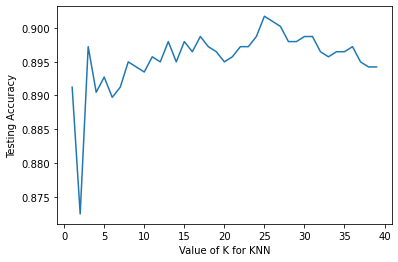

In [18]:
#plot out the possible knn neighbors and see which would perform best
plt.plot(k_range, scores)
plt.xlabel("Value of K for KNN")
plt.ylabel("Testing Accuracy")

In [19]:
#create new knn model
knn_cv = KNeighborsClassifier(n_neighbors=27)

#train new model with folds 
cv_scores = cross_val_score(knn_cv, x, y, cv=5)

#print the scores of each fold and the mean accuracy 
print(cv_scores)
print('cv_scores mean:{}'.format(np.mean(cv_scores)))

C:\Users\kieran\anaconda3\lib\site-packages\sklearn\model_selection\_split.py:670: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(("The least populated class in y has only %d"
C:\Users\kieran\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:531: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
C:\Users\kieran\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:531: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
C:\Users\kieran\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:531: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please

[0.7591898  0.92423106 0.89414414 0.86186186 0.84384384]
cv_scores mean:0.8566541410127307


C:\Users\kieran\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:531: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)


In [20]:
from sklearn.model_selection import GridSearchCV

knn2 = KNeighborsClassifier()

#create a range for all the values of k we want to test for
param_grid = {'n_neighbors':np.arange(1,30)}

#now use this grid search to test all values
knn_gscv = GridSearchCV(knn2, param_grid, cv=25)

#make the data fit
knn_gscv.fit(x, y)

C:\Users\kieran\anaconda3\lib\site-packages\sklearn\model_selection\_split.py:670: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=25.
  warnings.warn(("The least populated class in y has only %d"
C:\Users\kieran\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:531: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
C:\Users\kieran\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:531: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
C:\Users\kieran\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:531: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Pleas

GridSearchCV(cv=25, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29])})

In [21]:
#the best n_neighbor for k
knn_gscv.best_params_

{'n_neighbors': 17}

In [22]:
#best possible accuracy for knn
knn_gscv.best_score_

0.8935276393230268

In [23]:
from nltk.stem import WordNetLemmatizer

In [24]:
#import data on inactive users now
dataIA = 'D:/AI Course/AI Capstone Project/Inactive Accounts.csv'

In [25]:
DataIA = pd.read_csv(dataIA)

In [26]:
DataIA

,Section,Department,AccountExpires,LastLogon,Position,WorkforceCategory,ManagerPostReference,PostReference,PersonRefp3,EmplpoyeeNumberManager,...,StandardRate,ChargeRate,HoursPerWeek,HoursInvoicedToDate,JobTitleCode,SupplierName,CreatedDate,CreatedBy,UpdatedDate,UpdatedBy
0,Electoral Services,CEX - Corporate Services,28/07/2023 23:00,16/08/2022 11:18,Electoral Assistant,PC,1001887.0,1011484.0,1012639.0,606477.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Electoral Services,CEX - Corporate Services,28/07/2023 23:00,16/08/2022 11:18,Electoral Assistant,PC,1001887.0,1011484.0,1012639.0,606477.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Children's Social Care,Children's Services,NaN,05/05/2023 10:08,Social Worker,NaN,1003726.0,1014362.0,1066012.0,723006.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Standards and Attainment,Children and Young People,NaN,14/04/2023 09:22,Inclusion Support Outreach Teacher,LV,1010532.0,1006657.0,1069555.0,725314.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Standards and Attainment,Children and Young People,NaN,14/04/2023 09:22,Inclusion Support Outreach Teacher,LV,1013434.0,1010879.0,1036970.0,709967.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
570,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
571,Assessment and Care Management,Adult Services,28/04/2023 23:00,27/04/2023 13:13,SW Student,LV,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
572,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
573,NaN,Public Health,NaN,28/10/2022 13:52,Public Health Administrator,PP,1012237.0,1014055.0,1046002.0,713837.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
#we only want to look at non-NAN accounts as this data set contains temporary staff who have a lot of NAN data
df = DataIA[DataIA['Section'].notna()]
df

,Section,Department,AccountExpires,LastLogon,Position,WorkforceCategory,ManagerPostReference,PostReference,PersonRefp3,EmplpoyeeNumberManager,...,StandardRate,ChargeRate,HoursPerWeek,HoursInvoicedToDate,JobTitleCode,SupplierName,CreatedDate,CreatedBy,UpdatedDate,UpdatedBy
0,Electoral Services,CEX - Corporate Services,28/07/2023 23:00,16/08/2022 11:18,Electoral Assistant,PC,1001887.0,1011484.0,1012639.0,606477.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Electoral Services,CEX - Corporate Services,28/07/2023 23:00,16/08/2022 11:18,Electoral Assistant,PC,1001887.0,1011484.0,1012639.0,606477.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Children's Social Care,Children's Services,NaN,05/05/2023 10:08,Social Worker,NaN,1003726.0,1014362.0,1066012.0,723006.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Standards and Attainment,Children and Young People,NaN,14/04/2023 09:22,Inclusion Support Outreach Teacher,LV,1010532.0,1006657.0,1069555.0,725314.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Standards and Attainment,Children and Young People,NaN,14/04/2023 09:22,Inclusion Support Outreach Teacher,LV,1013434.0,1010879.0,1036970.0,709967.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,Children's Social Care,Children's Services,NaN,30/01/2023 16:43,Placement Officer,LV,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
566,Penge and Beckenham Locality Team,People's Department,NaN,17/03/2023 18:23,Care Manager,Wrong,NaN,NaN,NaN,NaN,...,0.0,0.00,36.0,0.0,2861,Diverse Financial Solutions Ltd ta/ Social Per...,34:02.0,LBB2000\devservice,34:03.0,LBB2000\devservice
567,Penge and Beckenham Locality Team,People's Department,NaN,17/03/2023 18:23,Care Manager,Wrong,NaN,NaN,NaN,NaN,...,24.3,32.92,36.0,0.0,3262,Diverse Financial Solutions Ltd ta/ Social Per...,34:03.0,LBB2000\devservice,34:02.0,LBB2000\devservice
571,Assessment and Care Management,Adult Services,28/04/2023 23:00,27/04/2023 13:13,SW Student,LV,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


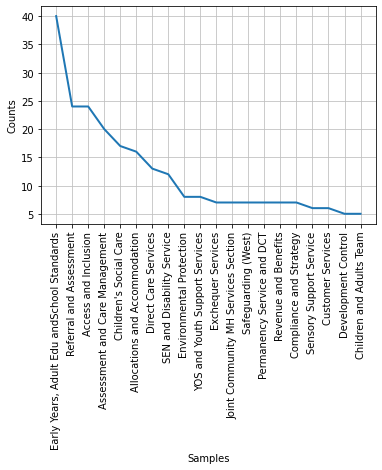

<AxesSubplot:xlabel='Samples', ylabel='Counts'>

In [28]:
#create a frequncy distribution of the Sections 
from nltk import FreqDist
fdist = FreqDist(df['Section'])
fdist.plot(20)

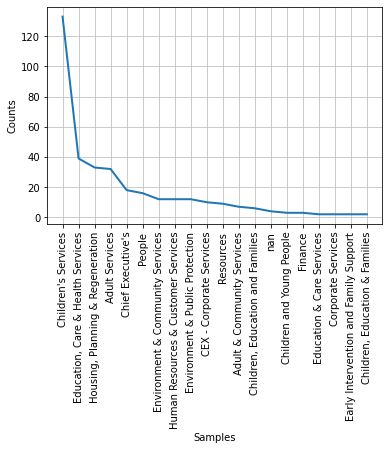

<AxesSubplot:xlabel='Samples', ylabel='Counts'>

In [29]:
#create a frequncy distribution of the Departments
from nltk import FreqDist
fdist = FreqDist(df['Department'])
fdist.plot(20)

In [30]:
#Count up users per department
df.value_counts('Department')

Department
Children's Services                      133
Education, Care & Health Services         39
Housing, Planning & Regeneration          33
Adult Services                            32
Chief Executive's                         18
People                                    16
Environment & Public Protection           12
Human Resources & Customer Services       12
Environment & Community Services          12
CEX - Corporate Services                  10
Resources                                  9
Adult & Community Services                 7
Children, Education and Families           6
Finance                                    3
Children and Young People                  3
Environmental Services                     2
Education & Care Services                  2
Early Intervention and Family Support      2
Corporate Services                         2
Children, Education & Families             2
People's Department                        2
Education, Care and Health Services        1

In [31]:
df

,Section,Department,AccountExpires,LastLogon,Position,WorkforceCategory,ManagerPostReference,PostReference,PersonRefp3,EmplpoyeeNumberManager,...,StandardRate,ChargeRate,HoursPerWeek,HoursInvoicedToDate,JobTitleCode,SupplierName,CreatedDate,CreatedBy,UpdatedDate,UpdatedBy
0,Electoral Services,CEX - Corporate Services,28/07/2023 23:00,16/08/2022 11:18,Electoral Assistant,PC,1001887.0,1011484.0,1012639.0,606477.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Electoral Services,CEX - Corporate Services,28/07/2023 23:00,16/08/2022 11:18,Electoral Assistant,PC,1001887.0,1011484.0,1012639.0,606477.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Children's Social Care,Children's Services,NaN,05/05/2023 10:08,Social Worker,NaN,1003726.0,1014362.0,1066012.0,723006.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Standards and Attainment,Children and Young People,NaN,14/04/2023 09:22,Inclusion Support Outreach Teacher,LV,1010532.0,1006657.0,1069555.0,725314.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Standards and Attainment,Children and Young People,NaN,14/04/2023 09:22,Inclusion Support Outreach Teacher,LV,1013434.0,1010879.0,1036970.0,709967.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,Children's Social Care,Children's Services,NaN,30/01/2023 16:43,Placement Officer,LV,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
566,Penge and Beckenham Locality Team,People's Department,NaN,17/03/2023 18:23,Care Manager,Wrong,NaN,NaN,NaN,NaN,...,0.0,0.00,36.0,0.0,2861,Diverse Financial Solutions Ltd ta/ Social Per...,34:02.0,LBB2000\devservice,34:03.0,LBB2000\devservice
567,Penge and Beckenham Locality Team,People's Department,NaN,17/03/2023 18:23,Care Manager,Wrong,NaN,NaN,NaN,NaN,...,24.3,32.92,36.0,0.0,3262,Diverse Financial Solutions Ltd ta/ Social Per...,34:03.0,LBB2000\devservice,34:02.0,LBB2000\devservice
571,Assessment and Care Management,Adult Services,28/04/2023 23:00,27/04/2023 13:13,SW Student,LV,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
from scipy.stats import chisquare

In [34]:
#what we expected vs what we obsevered
observed_data = [133, 39, 33, 32, 18, 16, 12, 12, 12, 10, 9,7,6,3,3,2,2,2,2,2,2,1,1,1,1,1,1,1]
expected_data = [14,14,13,14,13,13,13,13,14,13,13,13,13,13,13,13,13,13,13,13,13,13,13,13,13,13,13,13]

In [35]:
#goodness of fit 
chi_square_test_statistic, p_value = stats.chisquare(
        observed_data, expected_data)

#find the chi square test statistic and p value
print('chi_square_test_statistic is:' + 
      str(chi_square_test_statistic))
print('p_value:' + str(p_value))


#find chi-square critical value
print(stats.chi2.ppf(1-00.5,df=6))

chi_square_test_statistic is:1270.3406593406594
p_value:9.133613041399788e-251
5.348120627447118
